# **Visualization and Evaluation of Multivariate Networks through Dimensionality Reduction and Graph Embeddings**

**Published at the "GDxDR Workshop: Bridging Graph Drawing and Dimensionality Reduction", held during EuroVis 2026 in Nottingham, England (June 8–12, 2026).**


## Dependencies

- Python 3.10.3

In [3]:
# Core libraries
import numpy as np
import pandas as pd
import time
import os

# PyTorch and PyTorch Geometric
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.utils import from_networkx, add_self_loops, to_undirected, to_networkx, from_networkx, dropout_edge, to_networkx
from torch_geometric.nn import GCNConv, GATConv
from torch.nn import ReLU, Sequential, Linear
from torch_geometric.nn.models import GAE
from torch_geometric.datasets import Planetoid, Amazon

# Scikit-learn
from sklearn.preprocessing import MinMaxScaler
from sklearn.manifold import TSNE, trustworthiness
from sklearn.metrics import pairwise_distances, silhouette_score
from sklearn.utils.validation import check_symmetric
from sklearn.neighbors import NearestNeighbors

# Graph embedding libraries
from umap import UMAP
import networkx as nx

# Visualization
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# Statistics
from scipy.stats import hmean, wilcoxon
import random
from itertools import product
from math import prod

# Warmings
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="umap")

print("✓ Dependencies loaded")

✓ Dependencies loaded


## Data Loading

Amazon Computers is a segment of the Amazon co-purchase graph, where nodes represent
goods, edges indicate that two goods are frequently purchased together, and node features are bag-of-words-encoded product reviews. It contains 10 product categories: Computer Components,
Data Storage, Desktops, Laptops, Monitors, Networking Products,
Routers, Tablets, Video Projectors, and Webcams.



In [9]:
print("="*70)
print("DATA LOADING")
print("="*70)

# Load the dataset (Amazon Computer)
obj = torch.load('./data/amazon/Computers/processed/data.pt')
data = Data(**obj[0])

# Amazon has 13 classes with fixed semantic names
class_names = ["Desktops", "Data Storage", "Laptops", "Monitors", "Computer Components", "Video Projectors", "Routers", "Tablets", "Networking Products", "Webcams"]

# Convert to NetworkX graph (undirected by default)
G_cities_full = to_networkx(data, to_undirected=True)

print("Graph loaded from Amazon Computer dataset:")
print("  Nodes:", G_cities_full.number_of_nodes())
print("  Edges:", G_cities_full.number_of_edges())

# Extract largest connected component
components = list(nx.connected_components(G_cities_full))
largest_nodes = max(components, key=len)
G_cities = G_cities_full.subgraph(largest_nodes).copy()

print(f"\nLargest connected component:")
print(f"  Nodes: {G_cities.number_of_nodes()}")
print(f"  Edges: {G_cities.number_of_edges()}")
print(f"  Nodes excluded: {G_cities_full.number_of_nodes() - G_cities.number_of_nodes()}")

DATA LOADING
Graph loaded from Amazon Computer dataset:
  Nodes: 13752
  Edges: 245861

Largest connected component:
  Nodes: 13381
  Edges: 245778
  Nodes excluded: 371


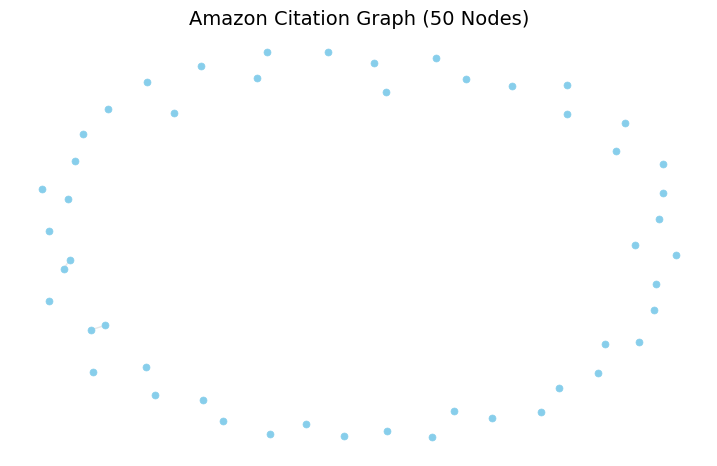

In [10]:
sub_nodes = list(G_cities.nodes())[:50]
H = G_cities.subgraph(sub_nodes)

# Generate positions for nodes
pos = nx.spring_layout(H, seed=42)

plt.figure(figsize=(12*0.75, 10*0.55))

# Draw nodes
nx.draw_networkx_nodes(H, pos,
                       node_size=25,
                       node_color='skyblue',
                       linewidths=0.5)

# Draw edges
nx.draw_networkx_edges(H, pos,
                        edge_color='#a0a0a0',
                        alpha=0.25)

plt.title("Amazon Citation Graph (50 Nodes)", fontsize=14)
plt.axis('off')
plt.show()

In [11]:
print("\nLoading node features and labels...")

# Assign features and labels to nodes in G_cities
for node_id in G_cities.nodes():
    G_cities.nodes[node_id]['features'] = data.x[node_id].tolist()
    G_cities.nodes[node_id]['label'] = class_names[int(data.y[node_id])]

# Get and print summary information
labels = list(nx.get_node_attributes(G_cities, 'label').values())
unique_labels = sorted(set(labels))
print(f"  Number of nodes: {G_cities.number_of_nodes()}")
print(f"  Feature dimension: {data.x.shape[1]}")
print(f"  Unique labels: {len(unique_labels)}")
print(f"  Labels: {unique_labels}")

print("\n✓ Node features and labels loaded")

# Create a DataFrame for easy inspection of node attributes
df_attr_raw = pd.DataFrame([
    {"Node Id": node_id, "Features": G_cities.nodes[node_id]['features'], "Categories": G_cities.nodes[node_id]['label']}
    for node_id in G_cities.nodes()
])
df_attr_raw


Loading node features and labels...
  Number of nodes: 13381
  Feature dimension: 767
  Unique labels: 10
  Labels: ['Computer Components', 'Data Storage', 'Desktops', 'Laptops', 'Monitors', 'Networking Products', 'Routers', 'Tablets', 'Video Projectors', 'Webcams']

✓ Node features and labels loaded


,Node Id,Features,Categories
0,0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",Computer Components
1,1,"[1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, ...",Computer Components
2,2,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ...",Networking Products
3,3,"[0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, ...",Computer Components
4,4,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, ...",Routers
...,...,...,...
13376,13747,"[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, ...",Data Storage
13377,13748,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",Computer Components
13378,13749,"[1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, ...",Networking Products
13379,13750,"[1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, ...",Computer Components


## Distance Matrices
Create precomputed distance matrices for attribute space and structure space.

In [12]:
print("\nCreating distance matrices...")

# Get ordered node list
nodes = list(G_cities.nodes())

# Size of dataset
DATASET_SIZE = G_cities.number_of_nodes()

# Extract feature matrix
X = np.array([G_cities.nodes[n]['features'] for n in nodes])

# Compute pairwise distances and scale
D_attr = check_symmetric(MinMaxScaler().fit_transform(pairwise_distances(X)), raise_warning=False)

# compute shortest path lengths between all pairs of nodes
p = dict(nx.shortest_path_length(G_cities))

# initialize distance matrix for edges (graph distances)
D_edges = np.zeros([DATASET_SIZE, DATASET_SIZE])

# fill distance matrix with shortest path lengths using node IDs
for i in range(DATASET_SIZE):
    for j in range(DATASET_SIZE):
        if nodes[j] in p[nodes[i]]:
            D_edges[i][j] = p[nodes[i]][nodes[j]]

# normalize distances to [0,1], ensure symmetry
D_edges = check_symmetric(MinMaxScaler().fit_transform(D_edges), raise_warning=False)

print(f"  D_attr shape: {D_attr.shape}")
print(f"  D_edges shape: {D_edges.shape}")
print("\n✓ Distance matrices created")


Creating distance matrices...
  D_attr shape: (13381, 13381)
  D_edges shape: (13381, 13381)

✓ Distance matrices created


## Hardware Detection
Detect available compute resources (MPS for Apple Silicon, CUDA for NVIDIA, or CPU).

In [13]:
def detect_hardware():
    """Detect available hardware and optimize settings"""
    if torch.backends.mps.is_available():
        device = torch.device("mps")
        print("✓ Apple Silicon MPS available")
        use_mps = True
    elif torch.cuda.is_available():
        device = torch.device("cuda")
        print("✓ NVIDIA GPU available")
        use_mps = False
    else:
        device = torch.device("cpu")
        print("✓ CPU only")
        use_mps = False

    cpu_count = os.cpu_count()
    optimal_workers = max(4, int(cpu_count * 0.75))

    print(f"CPU cores: {cpu_count}")
    print(f"Optimal workers: {optimal_workers}")
    print(f"Device: {device}")

    return device, optimal_workers, use_mps

DEVICE, NUM_WORKERS, USE_MPS = detect_hardware()

✓ NVIDIA GPU available
CPU cores: 48
Optimal workers: 36
Device: cuda


## Configuration
Define visualization parameters, dimensions and method-specific configurations.

In [14]:
# Visualization parameters: assign colors/shapes to unique labels
colors = ['orange', 'lightgreen', 'red', 'blue', 'purple', 'cyan', 'magenta', 'yellow', 'brown', 'pink']
shapes = ['o', 's', 'v', '^', '<', '>', 'p', '*', 'h', 'D']
VIS_PARAMS = [(colors[i % len(colors)], shapes[i % len(shapes)]) for i in range(len(unique_labels))]

# Group nodes by label
label_to_nodes = {label: [n for n in nodes if G_cities.nodes[n]['label'] == label]
                  for label in unique_labels}

# Create legend elements
legend_elements = [
    mlines.Line2D([], [], color=color, marker=shape, linestyle='None',
                  markersize=8, label=str(label))
    for (color, shape), label in zip(VIS_PARAMS, unique_labels)
]

# Embedding dimensions to test
DIMS = [2, 8, 16, 32, 64, 128, 256]

print(f"Dimensions to test: {DIMS}")

Dimensions to test: [2, 8, 16, 32, 64, 128, 256]


In [15]:
# Fix seed
SEED = 42

# Python
random.seed(SEED)
# Numpy
np.random.seed(SEED)
# PyTorch
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Determinismo CUDA
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## Utility Functions
Helper functions for graph models.

In [16]:
def format_time(seconds):
    """Convert seconds to MM:SS format"""
    m = int(seconds // 60)
    s = int(seconds % 60)
    return f"{m:02d}:{s:02d}"

print("✓ Utility functions loaded")

✓ Utility functions loaded


In [17]:
results = []

def store_result(result_dict, time_taken):
    """Store result with timing information"""
    result_dict['Time (s)'] = time_taken
    results.append(result_dict)

print("✓ Results storage initialized")

✓ Results storage initialized


## PyTorch Data Preparation
Prepare graph data for neural network methods.

In [18]:
# Extract labels
print(f"Data summary:")
print(f"  Nodes: {len(nodes)}")
print(f"  Features per node: {X.shape[1]}")
print(f"  Edges: {G_cities.number_of_edges()}")
print(f"  Classes: {len(unique_labels)}")

# Build feature matrix
feature_matrix = torch.tensor(
    [G_cities.nodes[n]['features'] for n in nodes],
    dtype=torch.float32
)

K = 30 # perplexity and n_neighbors
data = from_networkx(G_cities)
data.x = feature_matrix
data.edge_index = to_undirected(data.edge_index)
data.edge_index = add_self_loops(data.edge_index)[0]
data = data.to(DEVICE)
print()
print(data)
print("\n✓ Data prepared for all methods")

Data summary:
  Nodes: 13381
  Features per node: 767
  Edges: 245778
  Classes: 10

Data(edge_index=[2, 504937], features=[13381, 767], label=[13381], num_nodes=13381, x=[13381, 767])

✓ Data prepared for all methods


In [19]:
# edge_index: [2, num_edges]
src, dst = data.edge_index

# Create a set of edges as tuples
edges = set((s.item(), d.item()) for s, d in zip(src, dst))

# Check if all edges have the reverse
symmetric = all((d.item(), s.item()) in edges for s, d in zip(src, dst))

print("Graph is symmetric:", symmetric)

Graph is symmetric: True


## Metrics
Prepare Silhouette Score.

In [20]:
def calculate_silhouette_score(embedding, labels, seed=SEED):
    score = silhouette_score(
        embedding,
        labels,
        metric="cosine",
        random_state=seed
    )
    return score

# **RQ1. Does one modality (structure or attributes) tend to dominate neighborhood preservation?**


1. Get pair-wise distances of structure and attributes
2. Linear combine them
3. Plot
4. Define as baseline

In [ ]:
D_edges

array([[0.        , 0.26785714, 0.375     , ..., 0.40178571, 0.26785714,
        0.40178571],
       [0.26785714, 0.        , 0.26785714, ..., 0.42857143, 0.28571429,
        0.42857143],
       [0.375     , 0.26785714, 0.        , ..., 0.40178571, 0.26785714,
        0.26785714],
       ...,
       [0.40178571, 0.42857143, 0.40178571, ..., 0.        , 0.42857143,
        0.42857143],
       [0.26785714, 0.28571429, 0.26785714, ..., 0.42857143, 0.        ,
        0.42857143],
       [0.40178571, 0.42857143, 0.26785714, ..., 0.42857143, 0.42857143,
        0.        ]], shape=(13381, 13381))

In [ ]:
D_attr

array([[0.        , 0.88251388, 0.52447573, ..., 0.84826913, 0.50070886,
        0.68755045],
       [0.88251388, 0.        , 0.87246753, ..., 0.86228129, 0.82796543,
        0.86518641],
       [0.52447573, 0.87246753, 0.        , ..., 0.83784715, 0.61712231,
        0.72888988],
       ...,
       [0.84826913, 0.86228129, 0.83784715, ..., 0.        , 0.86583141,
        0.89631531],
       [0.50070886, 0.82796543, 0.61712231, ..., 0.86583141, 0.        ,
        0.72219675],
       [0.68755045, 0.86518641, 0.72888988, ..., 0.89631531, 0.72219675,
        0.        ]], shape=(13381, 13381))

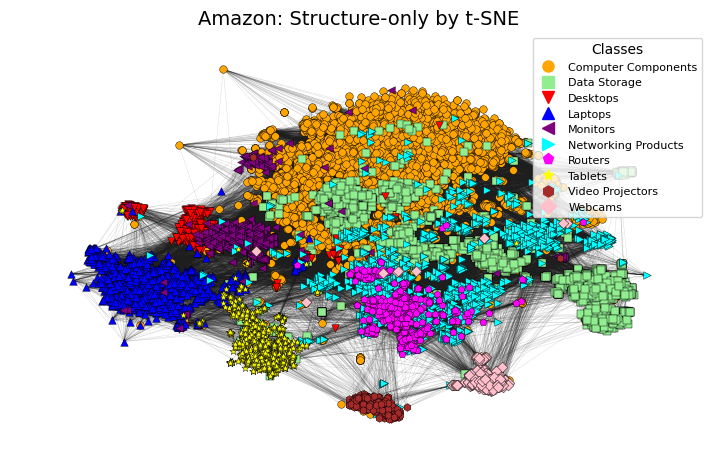

In [ ]:
# Embed nodes in 2D using t-SNE with precomputed distances
P_tsne_edges = TSNE(init='random', metric='precomputed', random_state=SEED, perplexity=K).fit_transform(D_edges)

# Create position dictionary: node ID → (x, y)
pos_network = {node: P_tsne_edges[i] for i, node in enumerate(nodes)}

# Draw nodes using the correct pos_network dictionary
plt.figure(figsize=(12*0.75, 10*0.55))
for i, label in enumerate(unique_labels):
    node_list = label_to_nodes[label]
    color, shape = VIS_PARAMS[i]
    nx.draw_networkx_nodes(G_cities, pos_network,
                           nodelist=node_list,
                           node_color=color,
                           node_shape=shape,
                           node_size=30,
                           edgecolors='k', linewidths=0.3)

# Draw edges
nx.draw_networkx_edges(G_cities, pos_network,
                        edge_color='#1E1E1E',
                        alpha=0.5,
                        width=0.1);

plt.legend(handles=legend_elements, title="Classes", loc="upper right", fontsize=8)
plt.title("Amazon: Structure-only by t-SNE", fontsize=14)
plt.axis('off')
plt.show()

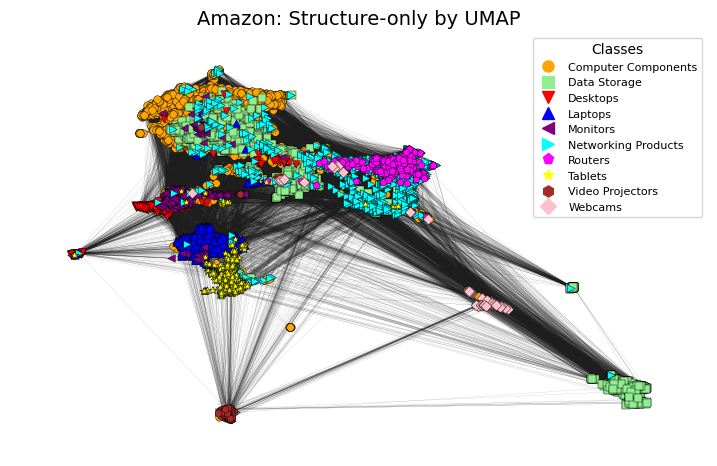

In [ ]:
# Embed nodes in 2D using UMAP with precomputed distances
P_umap_edges = UMAP(
        n_components=2,
        n_neighbors=K,
        metric="precomputed",
        random_state=SEED
    ).fit_transform(D_edges)

# Create position dictionary: node ID → (x, y)
pos_network = {node: P_umap_edges[i] for i, node in enumerate(nodes)}

# Draw nodes using the correct pos_network dictionary
plt.figure(figsize=(12*0.75, 10*0.55))
for i, label in enumerate(unique_labels):
    node_list = label_to_nodes[label]
    color, shape = VIS_PARAMS[i]
    nx.draw_networkx_nodes(G_cities, pos_network,
                           nodelist=node_list,
                           node_color=color,
                           node_shape=shape,
                           node_size=30,
                           edgecolors='k', linewidths=0.3)

# Draw edges
nx.draw_networkx_edges(G_cities, pos_network,
                        edge_color='#1E1E1E',
                        alpha=0.5,
                        width=0.1);

plt.legend(handles=legend_elements, title="Classes", loc="upper right", fontsize=8)
plt.title("Amazon: Structure-only by UMAP", fontsize=14)
plt.axis('off')
plt.show()

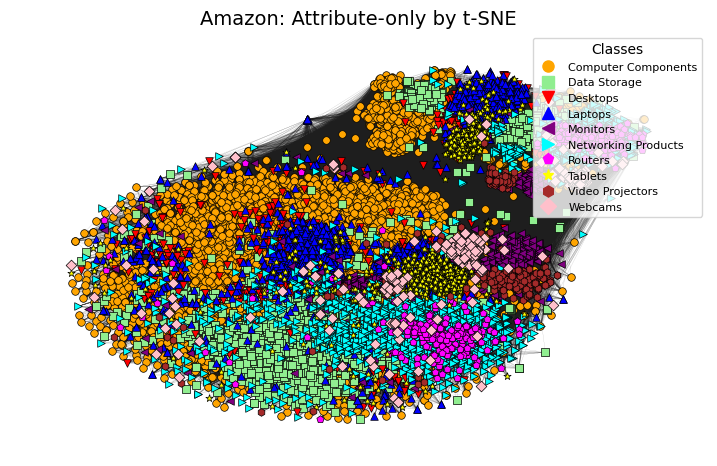

In [ ]:
# Embed in 2D using t-SNE
# If metric is "precomputed", X is assumed to be a distance matrix.
tsne_pos = TSNE(init='random', metric='precomputed', random_state=SEED, perplexity=K).fit_transform(D_attr)

P_tsne_attr = {node: pos for node, pos in zip(nodes, tsne_pos)}

# Draw each label cluster
plt.figure(figsize=(12*0.75, 10*0.55))
for i, label in enumerate(unique_labels):
    node_list = label_to_nodes[label]
    color, shape = VIS_PARAMS[i]
    nx.draw_networkx_nodes(G_cities, P_tsne_attr, nodelist=node_list,
                           node_color=color, node_shape=shape, node_size=30,
                           edgecolors='k', linewidths=0.5)

# Draw edges
nx.draw_networkx_edges(G_cities, P_tsne_attr,
                        edge_color='#1E1E1E',
                        alpha=0.5,
                        width=0.1)

plt.title("Amazon: Attribute-only by t-SNE", fontsize=14)
plt.axis('off')
plt.legend(handles=legend_elements, title="Classes", loc="upper right", fontsize=8)
plt.show()

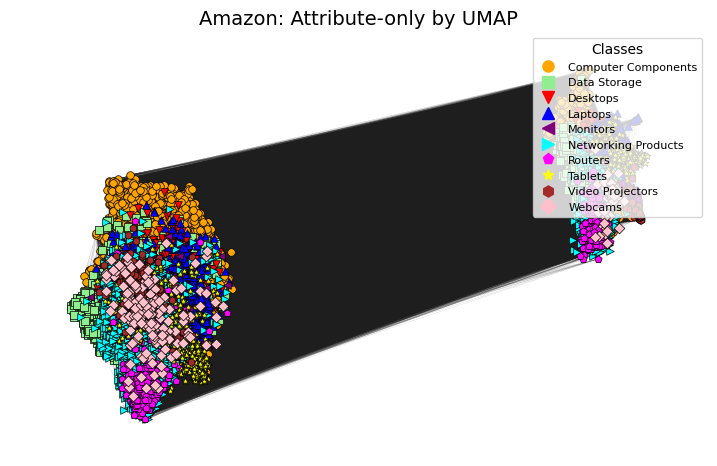

In [ ]:
# Embed in 2D using UMAP
# If metric is "precomputed", X is assumed to be a distance matrix.
umap_pos = UMAP(
        n_components=2,
        n_neighbors=K,
        metric="precomputed",
        random_state=SEED
    ).fit_transform(D_attr)

P_umap_attr = {node: pos for node, pos in zip(nodes, umap_pos)}

# Draw each label cluster
plt.figure(figsize=(12*0.75, 10*0.55))
for i, label in enumerate(unique_labels):
    node_list = label_to_nodes[label]
    color, shape = VIS_PARAMS[i]
    nx.draw_networkx_nodes(G_cities, P_umap_attr, nodelist=node_list,
                           node_color=color, node_shape=shape, node_size=30,
                           edgecolors='k', linewidths=0.5)

# Draw edges
nx.draw_networkx_edges(G_cities, P_umap_attr,
                        edge_color='#1E1E1E',
                        alpha=0.5,
                        width=0.1)

plt.title("Amazon: Attribute-only by UMAP", fontsize=14)
plt.axis('off')
plt.legend(handles=legend_elements, title="Classes", loc="upper right", fontsize=8)
plt.show()

**We have to find the best value for w, which is when Harmonic Trustworthiness achives the highest value.**

$$
D_{\text{comb}} = w\,D_{\text{structure}} + (w-1)\,D_{\text{attribute}}
$$



By t-SNE:

Best w (harmonic mean): 0.3793103448275862

Maximum harmonic mean of trustworthiness:

Silhouette score on Embedding (t-SNE):

By UMAP:

Best w (harmonic mean): 0.6551724137931034

Maximum harmonic mean of trustworthiness:

Silhouette score on Embedding (UMAP):




In [ ]:
best_w = 0.3793103448275862

D_comb = best_w * D_edges + (1-best_w) * D_attr

# t-SNE embedding
best_P_tsne_comb = TSNE(metric='precomputed', init='random', random_state=SEED, perplexity=K).fit_transform(D_comb)

# Calculate trustworthiness
trustworthiness_struc = trustworthiness(D_edges, best_P_tsne_comb, metric="precomputed", n_neighbors=K)
trustworthiness_attr = trustworthiness(D_attr, best_P_tsne_comb, metric="precomputed", n_neighbors=K)
trustworthinesss_harmonic = hmean([trustworthiness_struc, trustworthiness_attr])

print(f"Trustworthiness structure (t-SNE): {trustworthiness_struc:.4f}")
print(f"Trustworthiness attributes (t-SNE): {trustworthiness_attr:.4f}")
print(f"Harmonic Trustworthiness (t-SNE): {trustworthinesss_harmonic:.4f}")
print()
print(f"Silhouette score on Structure (t-SNE): {calculate_silhouette_score(P_tsne_edges, labels):.4f}")
print(f"Silhouette score on Attributes (t-SNE): {calculate_silhouette_score(tsne_pos, labels):.4f}")
print(f"Silhouette score on Embedding (t-SNE): {calculate_silhouette_score(best_P_tsne_comb, labels):.4f}")

Trustworthiness structure (t-SNE): 0.9114
Trustworthiness attributes (t-SNE): 0.7664
Harmonic Trustworthiness (t-SNE): 0.8327

Silhouette score on Structure (t-SNE): 0.0016
Silhouette score on Attributes (t-SNE): -0.1687
Silhouette score on Embedding (t-SNE): -0.1535


In [ ]:
best_w = 0.6551724137931034

D_comb_umap = best_w * D_edges + (1-best_w) * D_attr

# UMAP embedding
best_P_umap_comb = UMAP(
        n_components=2,
        n_neighbors=K,
        metric="precomputed",
        random_state=SEED
    ).fit_transform(D_comb_umap)

# Calculate trustworthiness
trustworthiness_struc = trustworthiness(D_edges, best_P_umap_comb, metric="precomputed", n_neighbors=K)
trustworthiness_attr = trustworthiness(D_attr, best_P_umap_comb, metric="precomputed", n_neighbors=K)
trustworthinesss_harmonic = hmean([trustworthiness_struc, trustworthiness_attr])

print(f"Trustworthiness structure (UMAP): {trustworthiness_struc:.4f}")
print(f"Trustworthiness attributes (UMAP): {trustworthiness_attr:.4f}")
print(f"Harmonic Trustworthiness (UMAP): {trustworthinesss_harmonic:.4f}")
print()
print(f"Silhouette score on Structure (UMAP): {calculate_silhouette_score(P_umap_edges, labels):.4f}")
print(f"Silhouette score on Attributes (UMAP): {calculate_silhouette_score(umap_pos, labels):.4f}")
print(f"Silhouette score on Embedding (UMAP): {calculate_silhouette_score(best_P_umap_comb, labels):.4f}")

Trustworthiness structure (UMAP): 0.8825
Trustworthiness attributes (UMAP): 0.7477
Harmonic Trustworthiness (UMAP): 0.8096

Silhouette score on Structure (UMAP): -0.4856
Silhouette score on Attributes (UMAP): -0.2832
Silhouette score on Embedding (UMAP): -0.2458


In [ ]:
"""
# Grid search
ws = np.linspace(0, 1, 30)

best_w = None
best_hmean = -np.inf
best_P_tsne_comb = None
harmonic_values = []
trustworthiness_struc_values = []
trustworthiness_attr_values = []

for w in ws:
    # Combined distance
    D_comb = w * D_edges + (1-w) * D_attr

    # t-SNE embedding
    P_tsne_comb = TSNE(metric='precomputed', init='random', random_state=SEED, perplexity=K).fit_transform(D_comb)

    # Compute trustworthiness separately
    trustworthiness_struc = trustworthiness(D_edges, P_tsne_comb, metric="precomputed", n_neighbors=K)
    trustworthiness_attr = trustworthiness(D_attr, P_tsne_comb, metric="precomputed", n_neighbors=K)

    # Harmonic mean
    trustworthiness_combined = hmean([trustworthiness_struc, trustworthiness_attr])

    # Append
    harmonic_values.append(trustworthiness_combined)
    trustworthiness_struc_values.append(trustworthiness_struc)
    trustworthiness_attr_values.append(trustworthiness_attr)

    if trustworthiness_combined > best_hmean:
        best_hmean = trustworthiness_combined
        best_w = w
        best_P_tsne_comb = P_tsne_comb

print("Best w (harmonic mean):", best_w)
print("Maximum harmonic mean of trustworthiness:", best_hmean)

# Plot
plt.figure(figsize=(12*0.75, 10*0.55))
plt.plot(ws, harmonic_values, marker='o', linestyle='--', color='blue', label='Harmonic mean')
plt.plot(ws, trustworthiness_struc_values, marker='^', linestyle='--', color='orange', label='Structure-based')
plt.plot(ws, trustworthiness_attr_values, marker='s', linestyle='--', color='green', label='Attribute-based')

# Highlight best w
plt.axvline(best_w, color='red', linestyle='--', label=f'Best w = {best_w:.2f}')

# Labels and title
plt.xlabel("w (weight for linear combination)")
plt.ylabel("Trustworthiness")
plt.title("Amazon: Trustworthiness vs Combination Weight w by t-SNE", fontsize=14)
plt.legend(loc='upper left', bbox_to_anchor=(1,1), fontsize=12)
plt.grid(True)
plt.xticks(ws[::3], fontsize=12)
plt.yticks(fontsize=12)
"""

'\n# Grid search\nws = np.linspace(0, 1, 30)\n\nbest_w = None\nbest_hmean = -np.inf\nbest_P_tsne_comb = None\nharmonic_values = []\ntrustworthiness_struc_values = []\ntrustworthiness_attr_values = []\n\nfor w in ws:\n    # Combined distance\n    D_comb = w * D_edges + (1-w) * D_attr\n\n    # t-SNE embedding\n    P_tsne_comb = TSNE(metric=\'precomputed\', init=\'random\', random_state=SEED, perplexity=K).fit_transform(D_comb)\n\n    # Compute trustworthiness separately\n    trustworthiness_struc = trustworthiness(D_edges, P_tsne_comb, metric="precomputed", n_neighbors=K)\n    trustworthiness_attr = trustworthiness(D_attr, P_tsne_comb, metric="precomputed", n_neighbors=K)\n\n    # Harmonic mean\n    trustworthiness_combined = hmean([trustworthiness_struc, trustworthiness_attr])\n\n    # Append\n    harmonic_values.append(trustworthiness_combined)\n    trustworthiness_struc_values.append(trustworthiness_struc)\n    trustworthiness_attr_values.append(trustworthiness_attr)\n\n    if trustwo

In [ ]:
"""
# Grid search
ws = np.concatenate([
    np.linspace(0, 1, 30),
])

best_w = None
best_hmean = -np.inf
best_P_umap_comb = None
harmonic_values = []
trustworthiness_struc_values = []
trustworthiness_attr_values = []

for w in ws:
    # Combined distance
    D_comb = w * D_edges + (1-w) * D_attr

    # UMAP embedding
    P_umap_comb = UMAP(
        n_components=2,
        n_neighbors=K,
        metric="precomputed",
        random_state=SEED
    ).fit_transform(D_comb)

    # Compute trustworthiness separately
    trustworthiness_structure = trustworthiness(D_edges, P_umap_comb, metric="precomputed", n_neighbors=K)
    trustworthiness_attributes = trustworthiness(D_attr, P_umap_comb, metric="precomputed", n_neighbors=K)

    # Harmonic mean
    trustworthiness_combined = hmean([trustworthiness_structure, trustworthiness_attributes])

    # Append
    harmonic_values.append(trustworthiness_combined)
    trustworthiness_struc_values.append(trustworthiness_structure)
    trustworthiness_attr_values.append(trustworthiness_attributes)

    if trustworthiness_combined > best_hmean:
        best_hmean = trustworthiness_combined
        best_w = w
        best_P_umap_comb = P_umap_comb

print("Best w (harmonic mean):", best_w)
print("Maximum harmonic mean of trustworthiness:", best_hmean)

# Plot
plt.figure(figsize=(12*0.75, 10*0.55))
plt.plot(ws, harmonic_values, marker='o', linestyle='--', color='blue', label='Harmonic mean')
plt.plot(ws, trustworthiness_struc_values, marker='^', linestyle='--', color='orange', label='Structure-based')
plt.plot(ws, trustworthiness_attr_values, marker='s', linestyle='--', color='green', label='Attribute-based')

# Highlight best w
plt.axvline(best_w, color='red', linestyle='--', label=f'Best w = {best_w:.2f}')

# Labels and title
plt.xlabel("w (weight for linear combination)")
plt.ylabel("Trustworthiness")
plt.title("Amazon: Trustworthiness vs Combination Weight w by UMAP", fontsize=14)
plt.legend(loc='upper left', bbox_to_anchor=(1,1), fontsize=12)
plt.grid(True)
plt.xticks(ws[::3], fontsize=12)
plt.yticks(fontsize=12)
"""

'\n# Grid search\nws = np.concatenate([\n    np.linspace(0, 1, 30),\n])\n\nbest_w = None\nbest_hmean = -np.inf\nbest_P_umap_comb = None\nharmonic_values = []\ntrustworthiness_struc_values = []\ntrustworthiness_attr_values = []\n\nfor w in ws:\n    # Combined distance\n    D_comb = w * D_edges + (1-w) * D_attr\n\n    # UMAP embedding\n    P_umap_comb = UMAP(\n        n_components=2,\n        n_neighbors=K,\n        metric="precomputed",\n        random_state=SEED\n    ).fit_transform(D_comb)\n\n    # Compute trustworthiness separately\n    trustworthiness_structure = trustworthiness(D_edges, P_umap_comb, metric="precomputed", n_neighbors=K)\n    trustworthiness_attributes = trustworthiness(D_attr, P_umap_comb, metric="precomputed", n_neighbors=K)\n\n    # Harmonic mean\n    trustworthiness_combined = hmean([trustworthiness_structure, trustworthiness_attributes])\n\n    # Append\n    harmonic_values.append(trustworthiness_combined)\n    trustworthiness_struc_values.append(trustworthiness

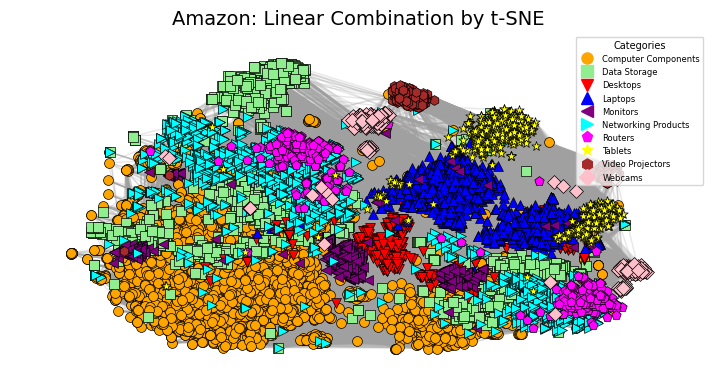

In [ ]:
pos_combined = {node: best_P_tsne_comb[i] for i, node in enumerate(nodes)}

# Draw each label cluster
plt.figure(figsize=(12*0.75, 10*0.45))
for i, label in enumerate(unique_labels):
    node_list = label_to_nodes[label]
    color, shape = VIS_PARAMS[i]
    nx.draw_networkx_nodes(G_cities, pos_combined,
                           nodelist=node_list,
                           node_color=color,
                           node_shape=shape,
                           node_size=50,
                         edgecolors='k', linewidths=0.5)

nx.draw_networkx_edges(G_cities, pos_combined, edge_color='#a0a0a0',
                        alpha=0.25)

plt.legend(handles=legend_elements, title="Categories", loc="upper right", fontsize=6, title_fontsize=7)
plt.title("Amazon: Linear Combination by t-SNE", fontsize=14)
plt.axis('off')

# Export figures
#plt.savefig("figures/rq1_amazon_tsne.svg", format="svg", bbox_inches="tight")
#plt.savefig("figures/rq1_amazon_tsne.pdf", format="pdf", bbox_inches="tight")
#plt.savefig("figures/rq1_amazon_tsne.png", format="png", dpi=300, bbox_inches="tight")

plt.show()

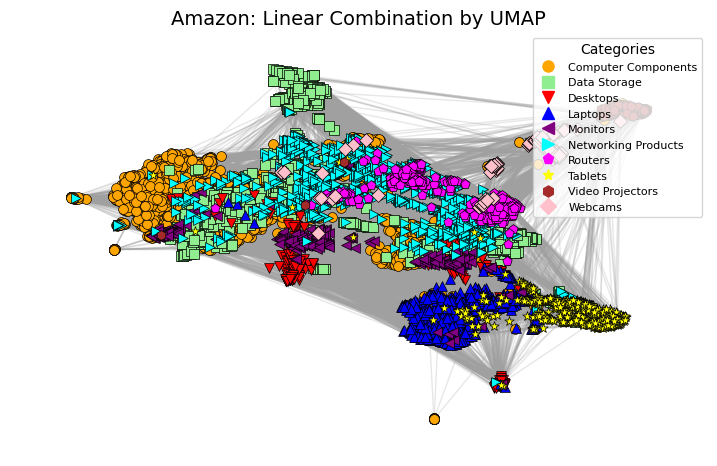

In [ ]:
pos_combined = {node: best_P_umap_comb[i] for i, node in enumerate(nodes)}

# Draw each label cluster
plt.figure(figsize=(12*0.75, 10*0.55))
for i, label in enumerate(unique_labels):
    node_list = label_to_nodes[label]
    color, shape = VIS_PARAMS[i]
    nx.draw_networkx_nodes(G_cities, pos_combined,
                           nodelist=node_list,
                           node_color=color,
                           node_shape=shape,
                           node_size=50,
                         edgecolors='k', linewidths=0.5)

nx.draw_networkx_edges(G_cities, pos_combined, edge_color='#a0a0a0',
                        alpha=0.25)

plt.legend(handles=legend_elements, title="Categories", loc="upper right", fontsize=8)
plt.title("Amazon: Linear Combination by UMAP", fontsize=14)
plt.axis('off')

# Export figures
"""
plt.savefig("rq1_amazon_umap.svg", format="svg", bbox_inches="tight")
plt.savefig("rq1_amazon_umap.pdf", format="pdf", bbox_inches="tight")
plt.savefig("rq1_amazon_umap.png", format="png", dpi=300, bbox_inches="tight")
"""

plt.show()

# **RQ2. How do different GE models compare in terms of neighborhood preservation?**

## Evaluation

In [21]:
def evaluate_embedding(emb, dim, method_name, reducer_used, config, seed=SEED):
    """
    Evaluate embedding using trustworthiness with metric='cosine'

    Args:
        emb: Embedding to evaluate
        dim: Dimensionality of the embedding
        method_name: Name of the method
        config: Configuration set

    Returns:
        Dictionary with evaluation results
    """
    # Ensure embedding is 2D
    if emb.ndim == 1:
        emb = emb.reshape(-1, 1)

    # For higher-dimensional embeddings, reduce to 2D for final evaluation
    if dim > 2:
      if reducer_used == 't-SNE':
        emb_2d = TSNE(n_components=2, init='random', random_state=seed, metric="cosine", perplexity=K).fit_transform(emb)

      elif reducer_used == 'UMAP':
        emb_2d = UMAP(n_components=2, random_state=seed, metric="cosine", n_neighbors=K).fit_transform(emb)

      reducer_used = 'with ' + reducer_used

    else:
        emb_2d = emb.numpy() # Convert PyTorch Tensor to NumPy array
        reducer_used = 'without Dimensionality Reduction'

    # Calculate trustworthiness
    trustworthiness_structure = trustworthiness(D_edges, emb_2d, metric="cosine", n_neighbors=K)
    trustworthiness_attributes = trustworthiness(D_attr, emb_2d, metric="cosine", n_neighbors=K)

    # Harmonic mean
    trustworthiness_harmonic = hmean([trustworthiness_structure, trustworthiness_attributes])

    return {
        'Method': method_name,
        'Config': config,
        'Dim': dim,
        'Reducer': reducer_used,
        'Embedding': emb_2d.copy(),
        'Trustworthiness Structure': trustworthiness_structure,
        'Trustworthiness Attributes': trustworthiness_attributes,
        'Harmonic Trustworthiness': trustworthiness_harmonic,
        'Silhouette Score': calculate_silhouette_score(emb_2d, labels)
    }

In [22]:
def plot_embedding_results(result, nodes, label_to_nodes, unique_labels, VIS_PARAMS, G_cities, legend_elements):
    """
    Plots the 2D embedding results for graph visualization.
    """

    pos_combined = {node: result['Embedding'][i] for i, node in enumerate(nodes)}

    plt.figure(figsize=(12*0.75, 10*0.55))
    for i, label in enumerate(unique_labels):
        node_list = label_to_nodes[label]
        color, shape = VIS_PARAMS[i]
        nx.draw_networkx_nodes(G_cities, pos_combined,
                               nodelist=node_list,
                               node_color=color,
                               node_shape=shape,
                               node_size=50,
                               edgecolors='k', linewidths=0.5)

    nx.draw_networkx_edges(G_cities, pos_combined, alpha=0.25, edge_color='#a0a0a0')

    plt.legend(handles=legend_elements, title="Classes", loc="upper right", fontsize=8)
    plt.title(f"Amazon: Best Graph Embedding ({result['Method']} - {result['Dim']}D) {result['Reducer']}", fontsize=14)
    plt.axis('off')
    plt.show()

## GNN Encoder Architectures

Reusable encoder classes for graph neural networks.


In [23]:
class GCNEncoder(torch.nn.Module):
    """2-layer GCN"""

    def __init__(self, in_ch, hidden_ch, out_ch, dropout):
        super().__init__()
        self.conv1 = GCNConv(in_ch, hidden_ch, add_self_loops=False)
        self.conv2 = GCNConv(hidden_ch, out_ch, add_self_loops=False)
        self.dropout = dropout
        self.reset_parameters()

    def reset_parameters(self):
        for conv in [self.conv1, self.conv2]:
            torch.nn.init.xavier_uniform_(conv.lin.weight)
            if conv.lin.bias is not None:
                torch.nn.init.zeros_(conv.lin.bias)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x

class GATEncoder(torch.nn.Module):
    """2-layer GAT with multi-head attention"""

    def __init__(self, in_ch, hidden_ch, out_ch,
                 heads, feat_dropout, attn_dropout):
        super().__init__()
        self.feat_dropout = feat_dropout

        self.gat1 = GATConv(in_ch, hidden_ch, heads=heads, dropout=attn_dropout, add_self_loops=False)

        self.gat2 = GATConv(hidden_ch * heads, out_ch, heads=1, concat=False, dropout=attn_dropout, add_self_loops=False)

        self.reset_parameters()

    def reset_parameters(self):
        for conv in [self.gat1, self.gat2]:

            if hasattr(conv, "lin") and conv.lin is not None:
                torch.nn.init.xavier_uniform_(conv.lin.weight)
                if conv.lin.bias is not None:
                    torch.nn.init.zeros_(conv.lin.bias)

            if hasattr(conv, "lin_src") and conv.lin_src is not None:
                torch.nn.init.xavier_uniform_(conv.lin_src.weight)
            if hasattr(conv, "lin_dst") and conv.lin_dst is not None:
                torch.nn.init.xavier_uniform_(conv.lin_dst.weight)

            torch.nn.init.xavier_uniform_(conv.att_src)
            torch.nn.init.xavier_uniform_(conv.att_dst)

            if conv.bias is not None:
                torch.nn.init.zeros_(conv.bias)

    def forward(self, x, edge_index):
        x = F.dropout(x, p=self.feat_dropout, training=self.training)
        x = self.gat1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=self.feat_dropout, training=self.training)
        x = self.gat2(x, edge_index)
        return x

class GraphCLEncoder(torch.nn.Module):
    """GCN encoder used in GraphCL"""

    def __init__(self, in_ch, hidden_ch, out_ch, dropout):
        super().__init__()

        self.conv1 = GCNConv(in_ch, hidden_ch, improved=False,add_self_loops=False)
        self.conv2 = GCNConv(hidden_ch, out_ch, improved=False,add_self_loops=False)

        self.dropout = dropout
        self.reset_parameters()

    def reset_parameters(self):
        for conv in [self.conv1, self.conv2]:
            torch.nn.init.xavier_uniform_(conv.lin.weight)
            if conv.lin.bias is not None:
                torch.nn.init.zeros_(conv.lin.bias)

    def forward(self, x, edge_index):
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x

print("✓ GNN encoders defined")

✓ GNN encoders defined


In [24]:
def train_gnn(
    encoder_class, data, dim,
    mode='gae',                # 'gae' or 'graphcl'
    device=DEVICE,
    encoder_name='GAE',
    hidden_dim=512,
    lr=1e-4,
    dropout=0.2,
    heads=8,               # used only if encoder is GAT
    max_epochs=100_000,
    patience=100,           # early stopping patience
    tau=0.5,               # temperature for GraphCL
    weight_decay=1e-4,     # L2 regularization
    attn_dropout=0.3,      # attention dropout
    log_every=5,
):
    """
    Unified training function for GAE (reconstruction) or GraphCL (contrastive).
    """
    # ----- Initialize encoder -----
    if encoder_name == 'GAT':
        enc = encoder_class(data.x.shape[1], hidden_dim, dim, heads=heads, feat_dropout=dropout, attn_dropout=attn_dropout).to(device)
    elif encoder_name == 'GAE':
        enc = encoder_class(data.x.shape[1], hidden_dim, dim, dropout=dropout).to(device)
    else:
        raise ValueError(f"Unsupported encoder: {encoder_name}")

    model = GAE(enc).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    # ----- Move data -----
    device = torch.device(device)
    x = data.x.to(device)
    edge_index = data.edge_index.to(device)

    best_loss = float('inf')
    patience_count = 0

    # ----- GraphCL contrastive loss -----
    def nt_xent_loss(z1, z2, tau):
        z1 = F.normalize(z1, dim=1)
        z2 = F.normalize(z2, dim=1)
        N = z1.size(0)
        z = torch.cat([z1, z2], dim=0)
        sim = torch.matmul(z, z.T) / tau
        mask = (~torch.eye(2*N, dtype=bool, device=z.device))
        sim = sim[mask].view(2*N, 2*N-1)
        pos = torch.exp(torch.sum(z1 * z2, dim=-1) / tau)
        pos = torch.cat([pos, pos], dim=0)
        loss = -torch.log(pos / torch.sum(torch.exp(sim), dim=1))
        return loss.mean()

    # ----- Training with statistical early stopping -----
    val_losses = []
    best_state = None

    model.train()
    for epoch in range(1, max_epochs+1):
        optimizer.zero_grad()

        if mode == 'gae':
            z = model.encode(x, edge_index)
            loss = model.recon_loss(z, edge_index)
        elif mode == 'graphcl':
            edge1, _ = dropout_edge(edge_index, p=dropout, force_undirected= True)
            edge2, _ = dropout_edge(edge_index, p=dropout,force_undirected= True)

            z1 = model.encode(x, edge1)
            z2 = model.encode(x, edge2)
            loss = nt_xent_loss(z1, z2, tau)

        else:
            raise ValueError(f"Unsupported mode: {mode}")


        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        val_loss = loss.item()
        val_losses.append(val_loss)

        # Update best weights
        if best_state is None or val_loss < min(val_losses[:-1]):
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        # Statistical early stopping
        if len(val_losses) > patience:
            recent_mean = np.mean(val_losses[-(patience + 1):-1])
            if val_losses[-1] > recent_mean:
                print(f"Early stopping at epoch {epoch}. Current loss: {val_losses[-1]:.4f}, mean of last {patience} epochs: {recent_mean:.4f}")
                break

        #if epoch % log_every == 0:
            #print(f"Epoch {epoch:04d} | Loss: {val_losses[-1]:.4f} | Best so far: {min(val_losses):.4f}")

    # ----- Restore best weights -----
    if best_state is not None:
        model.load_state_dict(best_state)

    # ----- Return final embeddings -----
    model.eval()
    with torch.no_grad():
        embeddings = model.encode(x, edge_index).cpu()

    return embeddings

## GCN (Graph Convolutional Network)




Spectral graph convolution with skip connections for improved gradient flow.


In [ ]:
print("GCN Embedding")
print("="*70)

# best one
params = {
  "lr": 0.01,
  "dropout": 0.8,
  "weight_decay": 0.001,
}

for d in DIMS:
  # Train
  start_train = time.time()
  emb = train_gnn(GCNEncoder, data, d, encoder_name='GAE', max_epochs=200, patience=10, **params)
  end_train = time.time() - start_train

  # Evaluate with tSNE
  start_evaluation = time.time()
  result = evaluate_embedding(emb, d, 'GCN', 't-SNE', params)
  end_evaluation = time.time() - start_evaluation
  store_result(result, end_train + end_evaluation)

  # Evaluate with UMAP
  start_evaluation = time.time()
  result = evaluate_embedding(emb, d, 'GCN', 'UMAP', params)
  end_evaluation = time.time() - start_evaluation
  store_result(result, end_train + end_evaluation)

## GraphCL (Graph Contrastive Learning)

Self-supervised learning through graph augmentation and contrastive loss.


In [ ]:
torch.cuda.empty_cache()

In [ ]:
print("GraphCL Embedding")
print("-" * 70)

# best one
params = {
  "lr": 0.01,
  "dropout": 0.8,
  "weight_decay": 0.001,
}

for d in DIMS:

  # Train
  start_train = time.time()
  emb = train_gnn(GraphCLEncoder, data, d, encoder_name='GAE', mode='graphcl', max_epochs=200, patience=10, **params)
  end_train = time.time() - start_train

  # Evaluate with tSNE
  start_evaluation = time.time()
  result = evaluate_embedding(emb, d, 'GraphCL', 't-SNE', params)
  end_evaluation = time.time() - start_evaluation
  store_result(result, end_train + end_evaluation)

  # Evaluate with UMAP
  start_evaluation = time.time()
  result = evaluate_embedding(emb, d, 'GraphCL', 'UMAP', params)
  end_evaluation = time.time() - start_evaluation
  store_result(result, end_train + end_evaluation)

## GAT (Graph Attention Network)

Uses multi-head attention mechanism to learn adaptive weights for neighbors.


In [ ]:
torch.cuda.empty_cache()

In [ ]:
print("GAT Embedding")
print("-" * 70)

# best one
params = {
  "lr": 0.01,
  "dropout": 0.6,
  "weight_decay": 0.01,
  "attn_dropout": 0.3
}

for d in DIMS:

  # Train
  start_train = time.time()
  emb = train_gnn(GATEncoder, data, d, encoder_name='GAT', max_epochs=100_000, patience=100, **params)
  end_train = time.time() - start_train

  # Evaluate with tSNE
  start_evaluation = time.time()
  result = evaluate_embedding(emb, d, 'GAT', 't-SNE', params)
  end_evaluation = time.time() - start_evaluation
  store_result(result, end_train + end_evaluation)

  # Evaluate with UMAP
  start_evaluation = time.time()
  result = evaluate_embedding(emb, d, 'GAT', 'UMAP', params)
  end_evaluation = time.time() - start_evaluation
  store_result(result, end_train + end_evaluation)

## Results Analysis
Analyze and display results.

In [ ]:
print("="*70)
print("RESULTS SUMMARY")
print("="*70)

# Create DataFrame
df = pd.DataFrame(results)

df = df.drop_duplicates(subset=['Method', 'Dim', 'Harmonic Trustworthiness', 'Silhouette Score'])

# Ajust time
df['Time (mm:ss)'] = df['Time (s)'].apply(format_time)

# --- Top Overall by Harmonic Trustworthiness ---
df_sorted = df.sort_values('Harmonic Trustworthiness', ascending=False)
print("\nTop Results (Overall by Harmonic Trustworthiness):")
display_cols = ['Method', 'Dim', 'Reducer', 'Harmonic Trustworthiness', 'Silhouette Score', 'Time (mm:ss)']
print(df_sorted[display_cols].to_string(index=False))

# --- Top per Method (only best per model) ---
print("\n" + "="*70)
print("Top Result per Method:")
print("="*70)

top_per_method = (
    df.sort_values("Harmonic Trustworthiness", ascending=False)
      .groupby("Method", as_index=False)
      .first()
)

print(
    top_per_method[display_cols]
        .sort_values("Harmonic Trustworthiness", ascending=False)
        .to_string(index=False)
)

# --- Top per Directly 2D (only best per model) ---
print("\n" + "="*70)
print("Top Result per Directly 2D:")
print("="*70)

top_per_2D = (
    df[df["Dim"] == 2]
      .sort_values("Harmonic Trustworthiness", ascending=False)
)

print(
    top_per_2D[display_cols]
        .to_string(index=False)
)

print("\n✓ Analysis complete")

RESULTS SUMMARY

Top Results (Overall by Harmonic Trustworthiness):
 Method  Dim                          Reducer  Harmonic Trustworthiness  Silhouette Score Time (mm:ss)
    GCN  256                       with t-SNE                  0.720567         -0.276631        01:19
    GCN  128                       with t-SNE                  0.719278         -0.248089        01:17
    GCN   64                       with t-SNE                  0.718378         -0.209298        01:17
GraphCL   64                       with t-SNE                  0.716144         -0.235018        01:18
    GCN   32                       with t-SNE                  0.715932         -0.335759        01:18
    GCN  256                        with UMAP                  0.712257         -0.060643        00:54
GraphCL    8                       with t-SNE                  0.712142         -0.359177        01:23
    GCN   16                       with t-SNE                  0.711984         -0.190532        01:17
    G

**Best Graph Embedding by Model**

In [ ]:
best_model_GCN = df_sorted[df_sorted["Method"]=="GCN"].iloc[0]   # the best GCN model

# Example usage
print("Best Model:", best_model_GCN)
print("Config: ", best_model_GCN["Config"])

Best Model: Method                                                                      GCN
Config                        {'lr': 0.01, 'dropout': 0.8, 'weight_decay': 0...
Dim                                                                         256
Reducer                                                              with t-SNE
Embedding                     [[-23.217516, -54.90163], [1.1398728, -50.0896...
Trustworthiness Structure                                              0.921556
Trustworthiness Attributes                                             0.591551
Harmonic Trustworthiness                                               0.720567
Silhouette Score                                                      -0.276631
Time (s)                                                              79.144815
Time (mm:ss)                                                              01:19
Name: 26, dtype: object
Config:  {'lr': 0.01, 'dropout': 0.8, 'weight_decay': 0.001}


In [ ]:
best_model_GAT = df_sorted[df_sorted["Method"]=="GAT"].iloc[0]   # the best GAT model

# Example usage
print("Best Model:", best_model_GAT)
print("Config: ", best_model_GAT["Config"])

Best Model: Method                                                                      GAT
Config                        {'lr': 0.01, 'dropout': 0.6, 'weight_decay': 0...
Dim                                                                          16
Reducer                                                              with t-SNE
Embedding                     [[-13.130674, -35.515564], [30.268934, -40.715...
Trustworthiness Structure                                              0.831974
Trustworthiness Attributes                                             0.607104
Harmonic Trustworthiness                                                0.70197
Silhouette Score                                                      -0.455502
Time (s)                                                             130.209008
Time (mm:ss)                                                              02:10
Name: 32, dtype: object
Config:  {'lr': 0.01, 'dropout': 0.6, 'weight_decay': 0.01, 'attn_dropout': 0.3}


In [ ]:
best_model_GraphCL = df_sorted[df_sorted["Method"]=="GraphCL"].iloc[0]   # the best GraphCL model

# Example usage
print("Best Model:", best_model_GraphCL)
print("Config: ", best_model_GraphCL["Config"])

Best Model: Method                                                                  GraphCL
Config                        {'lr': 0.01, 'dropout': 0.8, 'weight_decay': 0...
Dim                                                                          64
Reducer                                                              with t-SNE
Embedding                     [[4.918756, -18.240582], [0.34094495, -63.6594...
Trustworthiness Structure                                              0.915954
Trustworthiness Attributes                                             0.587897
Harmonic Trustworthiness                                               0.716144
Silhouette Score                                                      -0.235018
Time (s)                                                                78.3255
Time (mm:ss)                                                              01:18
Name: 8, dtype: object
Config:  {'lr': 0.01, 'dropout': 0.8, 'weight_decay': 0.001}


**Best Graph Embedding with t-SNE**

In [ ]:
best_model_tSNE = df_sorted[df_sorted["Reducer"]=="with t-SNE"].iloc[0]   # the best model

print("Best Model:", best_model_tSNE)

Best Model: Method                                                                      GCN
Config                        {'lr': 0.01, 'dropout': 0.8, 'weight_decay': 0...
Dim                                                                         256
Reducer                                                              with t-SNE
Embedding                     [[-23.217516, -54.90163], [1.1398728, -50.0896...
Trustworthiness Structure                                              0.921556
Trustworthiness Attributes                                             0.591551
Harmonic Trustworthiness                                               0.720567
Silhouette Score                                                      -0.276631
Time (s)                                                              79.144815
Time (mm:ss)                                                              01:19
Name: 26, dtype: object


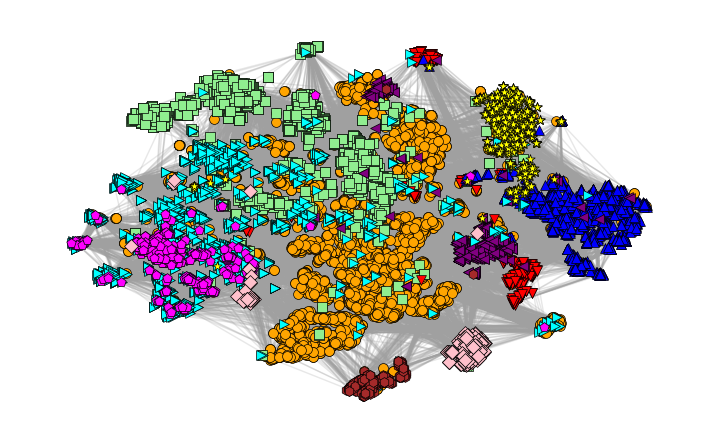

In [ ]:
pos_combined = {node: best_model_tSNE["Embedding"][i] for i, node in enumerate(nodes)}

# Draw each label cluster
plt.figure(figsize=(12*0.75, 10*0.55))
for i, label in enumerate(unique_labels):
    node_list = label_to_nodes[label]
    color, shape = VIS_PARAMS[i]
    nx.draw_networkx_nodes(G_cities, pos_combined,
                           nodelist=node_list,
                           node_color=color,
                           node_shape=shape,
                           node_size=50,
                         edgecolors='k', linewidths=0.5)

nx.draw_networkx_edges(G_cities, pos_combined, alpha=0.25, edge_color='#a0a0a0')

plt.legend(handles=legend_elements, title="Classes", loc="upper right", fontsize=9)
plt.title(f"Amazon: Best Graph Embedding ({best_model_tSNE.Method} - {best_model_tSNE.Dim}D) with t-SNE", fontsize=14)
plt.axis('off')
#plt.savefig("rq2_amazon_tsne.svg", format="svg", bbox_inches="tight")
#plt.savefig("rq2_amazon_tsne.pdf", format="pdf", bbox_inches="tight")
#plt.savefig("rq2_amazon_tsne.png", format="png", dpi=300, bbox_inches="tight")
plt.show()

**Best Graph Embedding with UMAP**

In [ ]:
best_model_UMAP = df_sorted[df_sorted["Reducer"]=="with UMAP"].iloc[0]   # the best model

print("Best Model:", best_model_UMAP)

Best Model: Method                                                                      GCN
Config                        {'lr': 0.01, 'dropout': 0.8, 'weight_decay': 0...
Dim                                                                         256
Reducer                                                               with UMAP
Embedding                     [[-4.9765925, -3.3613918], [-4.4837074, -5.672...
Trustworthiness Structure                                               0.91264
Trustworthiness Attributes                                             0.584026
Harmonic Trustworthiness                                               0.712257
Silhouette Score                                                      -0.060643
Time (s)                                                              54.207263
Time (mm:ss)                                                              00:54
Name: 27, dtype: object


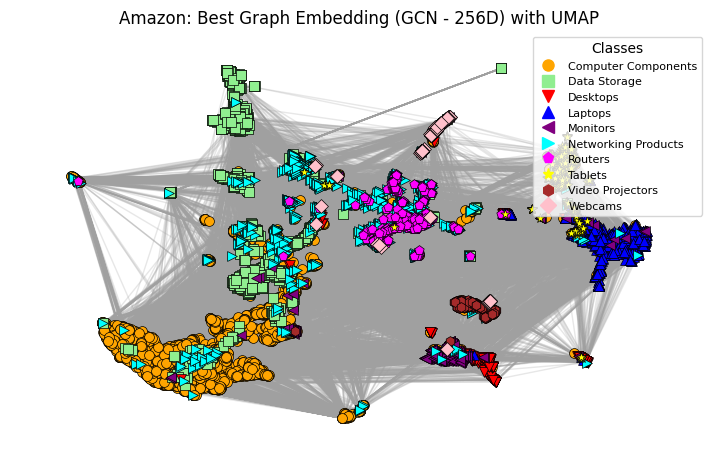

In [ ]:
pos_combined = {node: best_model_UMAP["Embedding"][i] for i, node in enumerate(nodes)}

# Draw each label cluster
plt.figure(figsize=(12*0.75, 10*0.55))
for i, label in enumerate(unique_labels):
    node_list = label_to_nodes[label]
    color, shape = VIS_PARAMS[i]
    nx.draw_networkx_nodes(G_cities, pos_combined,
                           nodelist=node_list,
                           node_color=color,
                           node_shape=shape,
                           node_size=50,
                         edgecolors='k', linewidths=0.5)

nx.draw_networkx_edges(G_cities, pos_combined, alpha=0.25, edge_color='#a0a0a0')

plt.legend(handles=legend_elements, title="Classes", loc="upper right", fontsize=8)
plt.title(f"Amazon: Best Graph Embedding ({best_model_UMAP.Method} - {best_model_UMAP.Dim}D) with UMAP")
plt.axis('off')
plt.show()

**Best Graph Embedding without Dimensionality Reduction**

In [ ]:
best_model_without_DR = top_per_2D.iloc[0]   # the best model

print("Best Model:", best_model_without_DR)

Best Model: Method                                                                      GCN
Config                        {'lr': 0.01, 'dropout': 0.8, 'weight_decay': 0...
Dim                                                                           2
Reducer                                        without Dimensionality Reduction
Embedding                     [[-8.964994, 2.8923557], [-30.073841, 9.858559...
Trustworthiness Structure                                              0.650859
Trustworthiness Attributes                                               0.6105
Harmonic Trustworthiness                                               0.630034
Silhouette Score                                                      -0.138445
Time (s)                                                              39.080406
Time (mm:ss)                                                              00:39
Name: 14, dtype: object


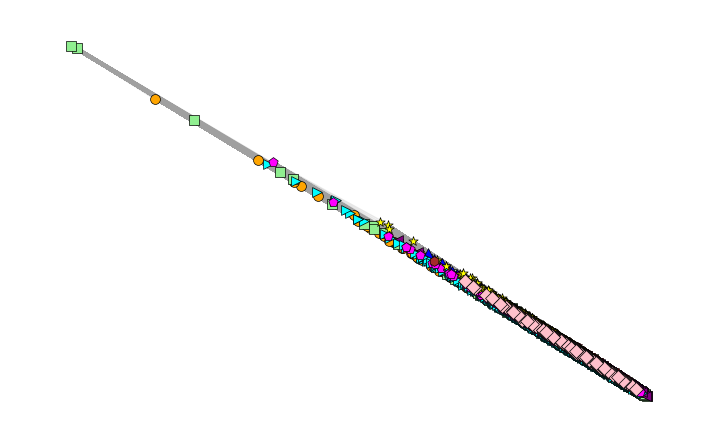

In [ ]:
pos_combined = {node: best_model_without_DR["Embedding"][i] for i, node in enumerate(nodes)}

# Draw each label cluster
plt.figure(figsize=(12*0.75, 10*0.55))
for i, label in enumerate(unique_labels):
    node_list = label_to_nodes[label]
    color, shape = VIS_PARAMS[i]
    nx.draw_networkx_nodes(G_cities, pos_combined,
                           nodelist=node_list,
                           node_color=color,
                           node_shape=shape,
                           node_size=50,
                         edgecolors='k', linewidths=0.5)

nx.draw_networkx_edges(G_cities, pos_combined, alpha=0.25, edge_color='#a0a0a0')

plt.legend(handles=legend_elements, title="Classes", loc="upper right", fontsize=9)
plt.title(f"Amazon: Best Graph Embedding ({best_model_without_DR.Method} - {best_model_without_DR.Dim}D) without DR", fontsize=14)
plt.axis('off')
#plt.savefig("rq2_amazon_without_dr.svg", format="svg", bbox_inches="tight")
#plt.savefig("rq2_amazon_without_dr.pdf", format="pdf", bbox_inches="tight")
#plt.savefig("rq2_amazon_without_dr.png", format="png", dpi=300, bbox_inches="tight")
plt.show()

# **Random Seeds**


In [25]:
# We define 20 seeds (Seed 42 + 19 seeds derived from pi decimal cases - 4 values each)
from mpmath import mp

# set precision high enough (need at least 77 decimal places = 19 * 4 + 1)
mp.dps = 80  # decimal places

# get pi digits as string and remove "3."
pi_str = str(mp.pi).replace(".", "")[1:]

num_seeds = 19
chunk_length = 4

ALL_SEEDS = [
    int(pi_str[i * chunk_length:(i + 1) * chunk_length])
    for i in range(num_seeds)
]

ALL_SEEDS.insert(0, SEED)  # add seed 42 at the beginning

print(ALL_SEEDS)
print("Unique seeds:", len(set(ALL_SEEDS)) == len(ALL_SEEDS)) # confirm if the seeds are unique

[42, 1415, 9265, 3589, 7932, 3846, 2643, 3832, 7950, 2884, 1971, 6939, 9375, 1058, 2097, 4944, 5923, 781, 6406, 2862]
Unique seeds: True


In [26]:
# All results
results_seeds = []

**Workflow 1 - Linear Combination**

In [27]:
# WORKFLOW 1 - t-SNE with best w found on SEED 42

for value_seed in ALL_SEEDS:
    # Python e NumPy random seeds
    random.seed(value_seed)
    np.random.seed(value_seed)

    best_w = 0.41379310344827586

    D_comb = best_w * D_edges + (1-best_w) * D_attr

    # t-SNE embedding
    best_P_tsne_comb = TSNE(metric='precomputed', init='random', random_state=value_seed, perplexity=K).fit_transform(D_comb)

    # Calculate trustworthiness
    trustworthiness_struc = trustworthiness(D_edges, best_P_tsne_comb, metric="precomputed", n_neighbors=K)
    trustworthiness_attr = trustworthiness(D_attr, best_P_tsne_comb, metric="precomputed", n_neighbors=K)
    trustworthinesss_harmonic = hmean([trustworthiness_struc, trustworthiness_attr])

    # Calculate silhouette score
    silhouette = calculate_silhouette_score(best_P_tsne_comb, labels, value_seed)

    # Results storage
    results_seeds.append({
        "Workflow": 1,
        "Method": "Linear Combination",
        "Dim": None,
        "DR": "t-SNE",
        "Struc_Trust": trustworthiness_struc,
        "Attr_Trust": trustworthiness_attr,
        "H_Trust": trustworthinesss_harmonic,
        "Silhouette": silhouette
    })

In [28]:
# WORKFLOW 1 - UMAP with best w found on SEED 42

for value_seed in ALL_SEEDS:
    # Python e NumPy random seeds
    random.seed(value_seed)
    np.random.seed(value_seed)

    best_w = 0.4482758620689655

    D_comb_umap = best_w * D_edges + (1-best_w) * D_attr

    # UMAP embedding
    best_P_umap_comb = UMAP(
            n_components=2,
            n_neighbors=K,
            metric="precomputed",
            random_state=value_seed
        ).fit_transform(D_comb_umap)

    # Calculate trustworthiness
    trustworthiness_struc = trustworthiness(D_edges, best_P_umap_comb, metric="precomputed", n_neighbors=K)
    trustworthiness_attr = trustworthiness(D_attr, best_P_umap_comb, metric="precomputed", n_neighbors=K)
    trustworthinesss_harmonic = hmean([trustworthiness_struc, trustworthiness_attr])

    # Calculate silhouette score
    silhouette = calculate_silhouette_score(best_P_umap_comb, labels, value_seed)

    # Results storage
    results_seeds.append({
        "Workflow": 1,
        "Method": "Linear Combination",
        "Dim": None,
        "DR": "UMAP",
        "Struc_Trust": trustworthiness_struc,
        "Attr_Trust": trustworthiness_attr,
        "H_Trust": trustworthinesss_harmonic,
        "Silhouette": silhouette
    })

**Workflow 2 - Graph Embedding**

In [29]:
# Train GCN
params = {
"lr": 0.01,
"dropout": 0.8,
"weight_decay": 0.001,
}

for value_seed in ALL_SEEDS:
    # Python, Numpy and PyTorch random seeds
    random.seed(value_seed)
    np.random.seed(value_seed)
    torch.manual_seed(value_seed)
    torch.cuda.manual_seed(value_seed)
    torch.cuda.manual_seed_all(value_seed)

    print(f"Evaluating GCN with seed {value_seed}")
    #for d in DIMS:
    for d in [2,256]:
        emb = train_gnn(GCNEncoder, data, d, encoder_name='GAE', max_epochs=200, patience=10, **params)
        if d > 2:
            value_metrics = evaluate_embedding(emb, d, 'GCN', 't-SNE', seed=value_seed, config=params)

            results_seeds.append({
                "Workflow": 2,
                "Method": "GCN",
                "Dim": d,
                "DR": value_metrics['Reducer'],
                "Struc_Trust": value_metrics['Trustworthiness Structure'],
                "Attr_Trust": value_metrics['Trustworthiness Attributes'],
                "H_Trust": value_metrics['Harmonic Trustworthiness'],
                "Silhouette": value_metrics['Silhouette Score']
            })

            value_metrics = evaluate_embedding(emb, d, 'GCN', 'UMAP', seed=value_seed, config=params)

            results_seeds.append({
                "Workflow": 2,
                "Method": "GCN",
                "Dim": d,
                "DR": value_metrics['Reducer'],
                "Struc_Trust": value_metrics['Trustworthiness Structure'],
                "Attr_Trust": value_metrics['Trustworthiness Attributes'],
                "H_Trust": value_metrics['Harmonic Trustworthiness'],
                "Silhouette": value_metrics['Silhouette Score']
            })
        else:
            value_metrics = evaluate_embedding(emb, d, 'GCN', None, seed=value_seed, config=params)

            results_seeds.append({
                "Workflow": 2,
                "Method": "GCN",
                "Dim": 2,
                "DR": None,
                "Struc_Trust": value_metrics['Trustworthiness Structure'],
                "Attr_Trust": value_metrics['Trustworthiness Attributes'],
                "H_Trust": value_metrics['Harmonic Trustworthiness'],
                "Silhouette": value_metrics['Silhouette Score']
            })

Evaluating GCN with seed 42
Early stopping at epoch 11. Current loss: 34.5388, mean of last 10 epochs: 31.2171
Early stopping at epoch 11. Current loss: 34.5388, mean of last 10 epochs: 33.7263
Evaluating GCN with seed 1415
Early stopping at epoch 11. Current loss: 34.5388, mean of last 10 epochs: 31.2159
Early stopping at epoch 11. Current loss: 34.5388, mean of last 10 epochs: 33.9626
Evaluating GCN with seed 9265
Early stopping at epoch 11. Current loss: 34.5388, mean of last 10 epochs: 31.2195
Early stopping at epoch 11. Current loss: 34.5388, mean of last 10 epochs: 33.5536
Evaluating GCN with seed 3589
Early stopping at epoch 11. Current loss: 34.5388, mean of last 10 epochs: 31.2141
Early stopping at epoch 11. Current loss: 34.5388, mean of last 10 epochs: 33.5894
Evaluating GCN with seed 7932
Early stopping at epoch 11. Current loss: 34.5388, mean of last 10 epochs: 31.2140
Early stopping at epoch 11. Current loss: 34.5388, mean of last 10 epochs: 33.1125
Evaluating GCN with se

In [30]:
torch.cuda.empty_cache()

In [31]:
# Train GraphCL with best params
params = {
  "lr": 0.01,
  "dropout": 0.8,
  "weight_decay": 0.001,
}

for value_seed in ALL_SEEDS:
    # Python, Numpy and PyTorch random seeds
    random.seed(value_seed)
    np.random.seed(value_seed)
    torch.manual_seed(value_seed)
    torch.cuda.manual_seed(value_seed)
    torch.cuda.manual_seed_all(value_seed)
    print(f"Evaluating GraphCL with seed {value_seed}")

    #for d in DIMS:
    for d in [2, 64]:
        emb = train_gnn(GraphCLEncoder, data, d, encoder_name='GAE', mode='graphcl', max_epochs=200, patience=10, **params)

        if d > 2:
            value_metrics = evaluate_embedding(emb, d, 'GraphCL', 't-SNE', seed=value_seed, config=params)

            results_seeds.append({
                "Workflow": 2,
                "Method": "GraphCL",
                "Dim": d,
                "DR": value_metrics['Reducer'],
                "Struc_Trust": value_metrics['Trustworthiness Structure'],
                "Attr_Trust": value_metrics['Trustworthiness Attributes'],
                "H_Trust": value_metrics['Harmonic Trustworthiness'],
                "Silhouette": value_metrics['Silhouette Score']
            })

            value_metrics = evaluate_embedding(emb, d, 'GraphCL', 'UMAP', seed=value_seed, config=params)

            results_seeds.append({
                "Workflow": 2,
                "Method": "GraphCL",
                "Dim": d,
                "DR": value_metrics['Reducer'],
                "Struc_Trust": value_metrics['Trustworthiness Structure'],
                "Attr_Trust": value_metrics['Trustworthiness Attributes'],
                "H_Trust": value_metrics['Harmonic Trustworthiness'],
                "Silhouette": value_metrics['Silhouette Score']
            })

        else:
            value_metrics = evaluate_embedding(emb, d, 'GraphCL', None, seed=value_seed, config=params)

            results_seeds.append({
                "Workflow": 2,
                "Method": "GraphCL",
                "Dim": 2,
                "DR": None,
                "Struc_Trust": value_metrics['Trustworthiness Structure'],
                "Attr_Trust": value_metrics['Trustworthiness Attributes'],
                "H_Trust": value_metrics['Harmonic Trustworthiness'],
                "Silhouette": value_metrics['Silhouette Score']
            })

Evaluating GraphCL with seed 42
Early stopping at epoch 23. Current loss: 10.1829, mean of last 10 epochs: 10.1819
Early stopping at epoch 46. Current loss: 9.2582, mean of last 10 epochs: 9.2200
Evaluating GraphCL with seed 1415
Early stopping at epoch 20. Current loss: 10.1830, mean of last 10 epochs: 10.1822
Early stopping at epoch 64. Current loss: 9.2102, mean of last 10 epochs: 9.1688
Evaluating GraphCL with seed 9265
Early stopping at epoch 26. Current loss: 10.1838, mean of last 10 epochs: 10.1798
Early stopping at epoch 11. Current loss: 10.1759, mean of last 10 epochs: 10.1673
Evaluating GraphCL with seed 3589
Early stopping at epoch 22. Current loss: 10.1844, mean of last 10 epochs: 10.1832
Early stopping at epoch 21. Current loss: 9.5808, mean of last 10 epochs: 9.5774
Evaluating GraphCL with seed 7932
Early stopping at epoch 20. Current loss: 10.1846, mean of last 10 epochs: 10.1833
Early stopping at epoch 66. Current loss: 9.2298, mean of last 10 epochs: 9.2268
Evaluating

In [32]:
torch.cuda.empty_cache()

In [33]:
# Train GAT with best params
params = {
  "lr": 0.01,
  "dropout": 0.6,
  "weight_decay": 0.01,
  "attn_dropout": 0.3
}

for value_seed in ALL_SEEDS:
    # Python, Numpy and PyTorch random seeds
    random.seed(value_seed)
    np.random.seed(value_seed)
    torch.manual_seed(value_seed)
    torch.cuda.manual_seed(value_seed)
    torch.cuda.manual_seed_all(value_seed)
    print(f"Evaluating GAT with seed {value_seed}")

    #for d in DIMS:
    for d in [2,16]:
        emb = train_gnn(GATEncoder, data, d, encoder_name='GAT', max_epochs=100_000, patience=100, **params)

        if d > 2:
            value_metrics = evaluate_embedding(emb, d, 'GAT', 't-SNE', seed=value_seed, config=params)

            results_seeds.append({
                "Workflow": 2,
                "Method": "GAT",
                "Dim": d,
                "DR": value_metrics['Reducer'],
                "Struc_Trust": value_metrics['Trustworthiness Structure'],
                "Attr_Trust": value_metrics['Trustworthiness Attributes'],
                "H_Trust": value_metrics['Harmonic Trustworthiness'],
                "Silhouette": value_metrics['Silhouette Score']
            })

            value_metrics = evaluate_embedding(emb, d, 'GAT', 'UMAP', seed=value_seed, config=params)

            results_seeds.append({
                "Workflow": 2,
                "Method": "GAT",
                "Dim": d,
                "DR": value_metrics['Reducer'],
                "Struc_Trust": value_metrics['Trustworthiness Structure'],
                "Attr_Trust": value_metrics['Trustworthiness Attributes'],
                "H_Trust": value_metrics['Harmonic Trustworthiness'],
                "Silhouette": value_metrics['Silhouette Score']
            })
        else:
            value_metrics = evaluate_embedding(emb, d, 'GAT', None, seed=value_seed, config=params)

            results_seeds.append({
                "Workflow": 2,
                "Method": "GAT",
                "Dim": 2,
                "DR": None,
                "Struc_Trust": value_metrics['Trustworthiness Structure'],
                "Attr_Trust": value_metrics['Trustworthiness Attributes'],
                "H_Trust": value_metrics['Harmonic Trustworthiness'],
                "Silhouette": value_metrics['Silhouette Score']
            })

Evaluating GAT with seed 42
Early stopping at epoch 102. Current loss: 19.3536, mean of last 100 epochs: 19.0019
Early stopping at epoch 143. Current loss: 18.1810, mean of last 100 epochs: 18.0316
Evaluating GAT with seed 1415
Early stopping at epoch 109. Current loss: 17.0314, mean of last 100 epochs: 16.9867
Early stopping at epoch 108. Current loss: 18.6424, mean of last 100 epochs: 18.6135
Evaluating GAT with seed 9265
Early stopping at epoch 105. Current loss: 22.5039, mean of last 100 epochs: 21.8659
Early stopping at epoch 112. Current loss: 17.3702, mean of last 100 epochs: 17.2139
Evaluating GAT with seed 3589
Early stopping at epoch 143. Current loss: 16.5088, mean of last 100 epochs: 16.3126
Early stopping at epoch 122. Current loss: 18.5891, mean of last 100 epochs: 18.2040
Evaluating GAT with seed 7932
Early stopping at epoch 183. Current loss: 17.4386, mean of last 100 epochs: 16.8446
Early stopping at epoch 127. Current loss: 18.1946, mean of last 100 epochs: 18.0092
Ev

In [34]:
torch.cuda.empty_cache()

**Results**

In [35]:
# build dataframe
df = pd.DataFrame(results_seeds)

# compute mean + sd
table = (
    df.groupby(["Workflow","Method","Dim","DR"], dropna=False)
      .agg(
          Struc_Trust_Mean=("Struc_Trust","mean"),
          Struc_Trust_SD=("Struc_Trust","std"),
          Attr_Trust_Mean=("Attr_Trust","mean"),
          Attr_Trust_SD=("Attr_Trust","std"),
          H_Trust_Mean=("H_Trust","mean"),
          H_Trust_SD=("H_Trust","std"),
          Silhouette_Mean=("Silhouette","mean"),
          Silhouette_SD=("Silhouette","std"),
      )
      .reset_index()
)

# make None readable
table["Dim"] = table["Dim"].fillna("∅").replace({256:"256",64:"64",16:"16"})
table["DR"] = table["DR"].fillna("∅").replace({"with t-SNE":"t-SNE", "with UMAP":"UMAP"})

# ranking
table = table.sort_values("H_Trust_Mean", ascending=False)

table.round(4).reset_index(drop=True)

,Workflow,Method,Dim,DR,Struc_Trust_Mean,Struc_Trust_SD,Attr_Trust_Mean,Attr_Trust_SD,H_Trust_Mean,H_Trust_SD,Silhouette_Mean,Silhouette_SD
0,1,Linear Combination,∅,t-SNE,0.9121,0.0007,0.7657,0.0004,0.8325,0.0004,-0.1251,0.0493
1,1,Linear Combination,∅,UMAP,0.8721,0.0007,0.7530,0.0007,0.8082,0.0005,-0.5199,0.0457
2,2,GCN,256,t-SNE,0.9213,0.0008,0.5906,0.0010,0.7198,0.0007,-0.2049,0.1039
3,2,GCN,256,UMAP,0.9116,0.0009,0.5833,0.0017,0.7114,0.0013,-0.0749,0.0680
4,2,GraphCL,64,t-SNE,0.8957,0.0220,0.5870,0.0097,0.7091,0.0123,-0.2328,0.0739
5,2,GraphCL,64,UMAP,0.8853,0.0215,0.5798,0.0092,0.7006,0.0121,-0.0823,0.1079
6,2,GAT,16,t-SNE,0.7759,0.0268,0.5915,0.0208,0.6709,0.0161,-0.2830,0.0709
7,2,GAT,16,UMAP,0.7384,0.0313,0.5842,0.0194,0.6518,0.0150,-0.4762,0.0794
8,2,GAT,2.0,∅,0.6923,0.0462,0.5542,0.0166,0.6148,0.0219,-0.3420,0.1165
9,2,GCN,2.0,∅,0.6075,0.0566,0.6087,0.0021,0.6070,0.0287,-0.4328,0.1388


In [39]:
# make None dims and DR readable
df["Dim"] = df["Dim"].fillna("Na").replace({2:"2",64:"64",128:"128"})
df["DR"] = df["DR"].fillna("Na").replace({"with t-SNE":"t-SNE", "with UMAP":"UMAP"})

df.groupby(["Workflow","Method","Dim","DR"], dropna=False)[["Struc_Trust", "Attr_Trust", "H_Trust","Silhouette"]].agg(["mean","std"]).round(4).sort_values(("H_Trust", "mean"), ascending=False)

Struc_Trust         Attr_Trust  \
                                               mean     std       mean   
Workflow Method             Dim   DR                                     
1        Linear Combination Na    t-SNE      0.9121  0.0007     0.7657   
                                  UMAP       0.8721  0.0007     0.7530   
2        GCN                256.0 t-SNE      0.9213  0.0008     0.5906   
                                  UMAP       0.9116  0.0009     0.5833   
         GraphCL            64    t-SNE      0.8957  0.0220     0.5870   
                                  UMAP       0.8853  0.0215     0.5798   
         GAT                16.0  t-SNE      0.7759  0.0268     0.5915   
                                  UMAP       0.7384  0.0313     0.5842   
                            2     Na         0.6923  0.0462     0.5542   
         GCN                2     Na         0.6075  0.0566     0.6087   
         GraphCL            2     Na         0.5708  0.0359     0.6103   

                                                H_Trust         Silhouette  \
                                            std    mean     std       mean   
Workflow Method             Dim   DR                                         
1        Linear Combination Na    t-SNE  0.0004  0.8325  0.0004    -0.1251   
                                  UMAP   0.0007  0.8082  0.0005    -0.5199   
2        GCN                256.0 t-SNE  0.0010  0.7198  0.0007    -0.2049   
                                  UMAP   0.0017  0.7114  0.0013    -0.0749   
         GraphCL            64    t-SNE  0.0097  0.7091  0.0123    -0.2328   
                                  UMAP   0.0092  0.7006  0.0121    -0.0823   
         GAT                16.0  t-SNE  0.0208  0.6709  0.0161    -0.2830   
                                  UMAP   0.0194  0.6518  0.0150    -0.4762   
                            2     Na     0.0166  0.6148  0.0219    -0.3420   
         GCN                2     Na     0.0021  0.6070  0.0287    -0.4328   
         GraphCL            2     Na     0.0024  0.5893  0.0184    -0.4482   

                                                 
                                            std  
Workflow Method             Dim   DR             
1        Linear Combination Na    t-SNE  0.0493  
                                  UMAP   0.0457  
2        GCN                256.0 t-SNE  0.1039  
                                  UMAP   0.0680  
         GraphCL            64    t-SNE  0.0739  
                                  UMAP   0.1079  
         GAT                16.0  t-SNE  0.0709  
                                  UMAP   0.0794  
                            2     Na     0.1165  
         GCN                2     Na     0.1388  
         GraphCL            2     Na     0.1208

In [37]:
# save to CSV
df.to_csv("results_seeds_amazon_computer.csv", index=False)

In [38]:
# 1) Configuration

# Columns that define one architecture
MODEL_COLS = ["Workflow", "Method", "Dim", "DR"]

# Metrics to evaluate
METRICS = ["Silhouette", "H_Trust"]

# Significance level
ALPHA = 0.05


# 2) Main evaluation function

def run_wilcoxon(df, metric):

    print("\n" + "=" * 70)
    print(f"METRIC: {metric}")
    print("=" * 70)

    # Group
    groups = df.groupby(MODEL_COLS)[metric]

    # Means
    means = groups.mean()

    # Best model
    best_model = means.idxmax()
    best_mean = means.max()

    print("\nBEST MODEL")
    print(best_model)
    print(f"Mean {metric}: {best_mean:.6f}")

    # Best scores
    best_scores = groups.get_group(best_model).values

    # Compare
    results = []

    for model, scores in groups:

        if model == best_model:
            continue

        scores = scores.values

        if len(scores) != len(best_scores):
            raise ValueError("Seed mismatch")

        stat, p = wilcoxon(best_scores, scores)

        results.append({
            "model": model,
            "mean": scores.mean(),
            "stat": stat,
            "pvalue": p,
            "significant": p < ALPHA
        })

    # Sort by mean
    results = sorted(
        results,
        key=lambda x: x["mean"],
        reverse=True
    )

    # Print
    print("\nCOMPARISON WITH BEST")
    print("-" * 70)

    for i, r in enumerate(results, 1):

        status = "SIGNIFICANT" if r["significant"] else "NOT significant"

        print(
            f"{i:2d}. {r['model']} | "
            f"mean={r['mean']:.6f} | "
            f"p={r['pvalue']:.4e} | "
            f"{status}"
        )

    print("-" * 70)

    # Find cutoff
    cutoff = None

    for i, r in enumerate(results, 1):
        if r["significant"]:
            cutoff = i
            break

    if cutoff is None:
        print("No significant difference with any model.")
    else:
        print(
            f"Significant difference starts from rank {cutoff}."
        )

    # Return results if you want to save later
    return results


# 3) Run for both metrics

all_results = {}

for metric in METRICS:
    all_results[metric] = run_wilcoxon(df, metric)


# 4) Save to CSV

for metric, res in all_results.items():

    out = pd.DataFrame(res)

    filename = f"wilcoxon_{metric}_amazon.csv"

    out.to_csv(filename, index=False)

    print(f"Saved: {filename}")


METRIC: Silhouette

BEST MODEL
(np.int64(2), 'GCN', 256.0, 'UMAP')
Mean Silhouette: -0.074912

COMPARISON WITH BEST
----------------------------------------------------------------------
 1. (np.int64(2), 'GraphCL', '64', 'UMAP') | mean=-0.082342 | p=9.8544e-01 | NOT significant
 2. (np.int64(1), 'Linear Combination', 'Na', 't-SNE') | mean=-0.125058 | p=1.3617e-02 | SIGNIFICANT
 3. (np.int64(2), 'GCN', 256.0, 't-SNE') | mean=-0.204896 | p=2.0981e-04 | SIGNIFICANT
 4. (np.int64(2), 'GraphCL', '64', 't-SNE') | mean=-0.232804 | p=3.8147e-06 | SIGNIFICANT
 5. (np.int64(2), 'GAT', 16.0, 't-SNE') | mean=-0.283019 | p=1.9073e-06 | SIGNIFICANT
 6. (np.int64(2), 'GAT', '2', 'Na') | mean=-0.341957 | p=1.9073e-06 | SIGNIFICANT
 7. (np.int64(2), 'GCN', '2', 'Na') | mean=-0.432756 | p=1.9073e-06 | SIGNIFICANT
 8. (np.int64(2), 'GraphCL', '2', 'Na') | mean=-0.448164 | p=1.9073e-06 | SIGNIFICANT
 9. (np.int64(2), 'GAT', 16.0, 'UMAP') | mean=-0.476182 | p=1.9073e-06 | SIGNIFICANT
10. (np.int64(1), 'L